In [21]:
"""
LIVE EARTHQUAKE TRACKER & ANALYSIS SYSTEM
==========================================
Complete pipeline: USGS data → Clustering → Risk Classification → Live Tracker

Features:
- ✅ Real-time USGS earthquake data
- ✅ Improved DBSCAN clustering with automatic eps tuning
- ✅ Proper K-Means with evaluation
- ✅ ML risk classification with SMOTE balancing
- ✅ Decision tree rules extraction
- ✅ Interactive visualizations
- ✅ Live earthquake tracker with severity map
- ✅ Forecast (ARIMA)
- ✅ Daily/weekly summaries

Run cell-by-cell in Jupyter to track earthquakes in real-time
"""

'\nLIVE EARTHQUAKE TRACKER & ANALYSIS SYSTEM\n==========================================\nComplete pipeline: USGS data → Clustering → Risk Classification → Live Tracker\n\nFeatures:\n- ✅ Real-time USGS earthquake data\n- ✅ Improved DBSCAN clustering with automatic eps tuning\n- ✅ Proper K-Means with evaluation\n- ✅ ML risk classification with SMOTE balancing\n- ✅ Decision tree rules extraction\n- ✅ Interactive visualizations\n- ✅ Live earthquake tracker with severity map\n- ✅ Forecast (ARIMA)\n- ✅ Daily/weekly summaries\n\nRun cell-by-cell in Jupyter to track earthquakes in real-time\n'

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [23]:
# USGS Data
import requests
import json

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.signal import argrelextrema


In [24]:
# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, silhouette_score, 
                             davies_bouldin_score, calinski_harabasz_score)

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Time series
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Visualization
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.gridspec as gridspec


In [25]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"Current time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S UTC')}")



✅ All imports successful!
Current time: 2026-03-07 07:21:26 UTC


In [52]:
csv_path = 'D:/Advanced Data Mining/Final/earthquake_data_1960_2023.csv'

In [55]:
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\harsh\AppData\Local\Programs\Microsoft VS Code


In [54]:
# ============================================================================
# CELL 2: LOAD YOUR EARTHQUAKE DATA FROM CSV
# ============================================================================

def load_earthquake_data_from_csv(csv_path):
    """
    Load earthquake data from your CSV file.
    """
    
    print(f"\n{'='*70}")
    print(f"LOADING EARTHQUAKE DATA FROM CSV: {csv_path}")
    print(f"{'='*70}")
    
    try:
        # Load CSV
        df = pd.read_csv(csv_path)
        
        # Convert Time to datetime
        df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
        
        # Remove rows with missing Time
        df = df.dropna(subset=['Time'])
        
        # Remove duplicates
        df = df.drop_duplicates(subset=['ID'] if 'ID' in df.columns else ['Time', 'Latitude', 'Longitude'])
        
        # Sort by time (newest first)
        df = df.sort_values('Time', ascending=False).reset_index(drop=True)
        
        print(f"\n✅ Successfully loaded earthquake data from CSV")
        print(f"  Total records: {len(df)}")
        print(f"  Magnitude range: {df['Mag'].min():.1f} - {df['Mag'].max():.1f}")
        print(f"  Depth range: {df['Depth'].min():.1f} - {df['Depth'].max():.1f} km")
        print(f"  Date range: {df['Time'].min().date()} to {df['Time'].max().date()}")
        print(f"  Columns: {list(df.columns)}")
        
        return df
    
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
        print("Using USGS API as fallback...")
        return fetch_usgs_earthquake_data(days_back=30, min_magnitude=4.5)
    
    except Exception as e:
        print(f"❌ Error loading CSV: {e}")
        print("Using USGS API as fallback...")
        return fetch_usgs_earthquake_data(days_back=30, min_magnitude=4.5)


# Load your data
earthquake_data = load_earthquake_data_from_csv('earthquake_data_1960_2023.csv')

print("\n✅ Data loaded and ready for analysis")


LOADING EARTHQUAKE DATA FROM CSV: earthquake_data_1960_2023.csv
❌ File not found: earthquake_data_1960_2023.csv
Using USGS API as fallback...

FETCHING USGS EARTHQUAKE DATA (30 days, M>4.5)
URL: https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/magnitude_4.5_week.geojson
Date range: 2026-02-05 to 2026-03-07
❌ Error fetching data: Extra data: line 1 column 5 (char 4)
Creating synthetic data for demonstration...

✅ Data loaded and ready for analysis


In [26]:
# ============================================================================
# CELL 2: FETCH LIVE USGS EARTHQUAKE DATA
# ============================================================================

def fetch_usgs_earthquake_data(days_back=30, min_magnitude=4.5):
    """
    Fetch earthquake data from USGS Earthquake Hazards Program API
    
    Parameters:
    -----------
    days_back : int
        Number of days to look back (default 30 days)
    min_magnitude : float
        Minimum magnitude to include (default 4.5)
    
    Returns:
    --------
    df : DataFrame
        Cleaned earthquake data with columns:
        Time, Place, Latitude, Longitude, Depth, Mag, MagType
    """
    
    print(f"\n{'='*70}")
    print(f"FETCHING USGS EARTHQUAKE DATA ({days_back} days, M>{min_magnitude})")
    print(f"{'='*70}")
    
    # Build USGS API URL
    start_time = (datetime.utcnow() - timedelta(days=days_back)).strftime('%Y-%m-%d')
    end_time = datetime.utcnow().strftime('%Y-%m-%d')
    
    url = (
        f"https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/"
        f"magnitude_{min_magnitude}_week.geojson"
    )
    
    print(f"URL: {url}")
    print(f"Date range: {start_time} to {end_time}")
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        print(f"✅ Successfully fetched {len(data['features'])} earthquakes")
        
        # Parse data
        earthquakes = []
        for feature in data['features']:
            props = feature['properties']
            coords = feature['geometry']['coordinates']
            
            earthquakes.append({
                'Time': pd.to_datetime(props['time'], unit='ms'),
                'Place': props.get('place', 'Unknown'),
                'Longitude': coords[0],
                'Latitude': coords[1],
                'Depth': coords[2],
                'Mag': props['mag'],
                'MagType': props.get('magType', 'Unknown'),
                'ID': props['id'],
                'URL': props.get('url', '')
            })
        
        df = pd.DataFrame(earthquakes)
        
        # Convert to UTC and remove duplicates
        df['Time'] = df['Time'].dt.tz_localize(None)
        df = df.drop_duplicates(subset=['ID']).reset_index(drop=True)
        
        # Sort by time
        df = df.sort_values('Time', ascending=False).reset_index(drop=True)
        
        print(f"\n✅ Data Summary:")
        print(f"  Total records: {len(df)}")
        print(f"  Magnitude range: {df['Mag'].min():.1f} - {df['Mag'].max():.1f}")
        print(f"  Depth range: {df['Depth'].min():.1f} - {df['Depth'].max():.1f} km")
        print(f"  Date range: {df['Time'].min().date()} to {df['Time'].max().date()}")
        
        return df
    
    except requests.exceptions.RequestException as e:
        print(f"❌ Error fetching data: {e}")
        print("Creating synthetic data for demonstration...")
        return create_synthetic_earthquake_data(100)



In [27]:
def create_synthetic_earthquake_data(n_samples=100):
    """Create synthetic earthquake data for testing."""
    np.random.seed(42)
    
    # Pacific Ring of Fire clusters
    clusters = [
        {'center': (37, -122), 'name': 'San Francisco'},      # California
        {'center': (-37, 175), 'name': 'New Zealand'},        # NZ
        {'center': (1, 120), 'name': 'Indonesia'},            # Indonesia
        {'center': (-10, -70), 'name': 'South America'},      # Peru/Chile
        {'center': (40, 142), 'name': 'Japan'},               # Japan
    ]
    
    earthquakes = []
    for i in range(n_samples):
        cluster = clusters[i % len(clusters)]
        
        lat = cluster['center'][0] + np.random.normal(0, 3)
        lon = cluster['center'][1] + np.random.normal(0, 3)
        depth = np.random.exponential(50) + 5
        mag = np.random.normal(5.5, 0.8)
        mag = np.clip(mag, 4.5, 8.5)
        
        earthquakes.append({
            'Time': datetime.utcnow() - timedelta(days=np.random.randint(0, 30)),
            'Place': cluster['name'],
            'Latitude': lat,
            'Longitude': lon,
            'Depth': depth,
            'Mag': mag,
            'MagType': 'mww',
            'ID': f'synthetic_{i}',
            'URL': ''
        })
    
    return pd.DataFrame(earthquakes).sort_values('Time', ascending=False).reset_index(drop=True)


# Fetch data
earthquake_data = fetch_usgs_earthquake_data(days_back=30, min_magnitude=4.5)
print("\n✅ Data loaded and ready for analysis")




FETCHING USGS EARTHQUAKE DATA (30 days, M>4.5)
URL: https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/magnitude_4.5_week.geojson
Date range: 2026-02-05 to 2026-03-07
❌ Error fetching data: Extra data: line 1 column 5 (char 4)
Creating synthetic data for demonstration...

✅ Data loaded and ready for analysis


In [28]:
print(earthquake_data.head())

                        Time          Place   Latitude   Longitude      Depth  \
0 2026-03-07 12:21:26.911737  South America -15.075455  -68.454857  85.047497   
1 2026-03-07 12:21:26.911699    New Zealand -36.538825  178.172271  72.501712   
2 2026-03-07 12:21:26.911517    New Zealand -40.281821  178.148042  17.697493   
3 2026-03-07 12:21:26.911389          Japan  36.813089  143.420777  63.710626   
4 2026-03-07 12:21:26.911178          Japan  35.951830  138.942782  13.995574   

        Mag MagType            ID URL  
0  8.500000     mww  synthetic_53      
1  5.541089     mww  synthetic_51      
2  6.560085     mww  synthetic_41      
3  5.996439     mww  synthetic_34      
4  4.500000     mww  synthetic_24      


In [29]:

# ============================================================================
# CELL 3: DATA PREPROCESSING & RISK CLASSIFICATION
# ============================================================================

def preprocess_earthquake_data(df):
    """
    Preprocess earthquake data for analysis.
    
    Returns:
    --------
    df_clean : DataFrame
        Cleaned data with additional features
    """
    
    print(f"\n{'='*70}")
    print("DATA PREPROCESSING")
    print(f"{'='*70}")
    
    df_clean = df.copy()
    
    # Remove rows with missing values in critical columns
    critical_cols = ['Latitude', 'Longitude', 'Depth', 'Mag', 'Time']
    df_clean = df_clean.dropna(subset=critical_cols)
    
    print(f"✅ Removed rows with missing values: {len(df)} → {len(df_clean)}")
    
    # Add temporal features
    df_clean['Year'] = df_clean['Time'].dt.year
    df_clean['Month'] = df_clean['Time'].dt.month
    df_clean['DayOfYear'] = df_clean['Time'].dt.dayofyear
    df_clean['Hour'] = df_clean['Time'].dt.hour
    df_clean['WeekOfYear'] = df_clean['Time'].dt.isocalendar().week
    
    # Risk classification (3-class: Low, Moderate, High)
    def classify_risk(magnitude):
        if magnitude < 5.5:
            return 0  # Low
        elif 5.5 <= magnitude < 6.5:
            return 1  # Moderate
        else:
            return 2  # High
    
    df_clean['Risk_Category'] = df_clean['Mag'].apply(classify_risk)
    risk_names = {0: 'Low', 1: 'Moderate', 2: 'High'}
    df_clean['Risk_Name'] = df_clean['Risk_Category'].map(risk_names)
    
    # Earthquake depth categories
    df_clean['Depth_Category'] = pd.cut(
        df_clean['Depth'],
        bins=[0, 50, 100, 300, 700],
        labels=['Shallow', 'Intermediate', 'Deep', 'Very Deep']
    )
    
    print(f"\n✅ Temporal features added:")
    print(f"  - Year, Month, DayOfYear, Hour, WeekOfYear")
    print(f"  - Risk_Category (0=Low, 1=Moderate, 2=High)")
    print(f"  - Depth_Category (Shallow/Intermediate/Deep/Very Deep)")
    
    print(f"\n✅ Risk Distribution:")
    for risk_id, risk_name in risk_names.items():
        count = (df_clean['Risk_Category'] == risk_id).sum()
        pct = 100 * count / len(df_clean)
        print(f"  {risk_name:12s}: {count:4d} ({pct:5.1f}%)")
    
    return df_clean


In [30]:

df_processed = preprocess_earthquake_data(earthquake_data)
print("\n✅ Preprocessing complete")




DATA PREPROCESSING
✅ Removed rows with missing values: 100 → 100

✅ Temporal features added:
  - Year, Month, DayOfYear, Hour, WeekOfYear
  - Risk_Category (0=Low, 1=Moderate, 2=High)
  - Depth_Category (Shallow/Intermediate/Deep/Very Deep)

✅ Risk Distribution:
  Low         :   50 ( 50.0%)
  Moderate    :   37 ( 37.0%)
  High        :   13 ( 13.0%)

✅ Preprocessing complete


In [31]:
# ============================================================================
# CELL 4: OPTIMAL DBSCAN PARAMETER TUNING (K-DISTANCE GRAPH)
# ============================================================================

def estimate_optimal_eps(scaled_data, min_samples=10, plot=True):
    """
    Estimate optimal eps using k-distance graph.
    """
    
    print(f"\n{'='*70}")
    print("ESTIMATING OPTIMAL EPS FOR DBSCAN (K-DISTANCE GRAPH)")
    print(f"{'='*70}")
    
    # Compute k-nearest neighbors
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(scaled_data)
    distances, indices = neighbors.kneighbors(scaled_data)
    distances = np.sort(distances[:, min_samples - 1], axis=0)
    
    # Find knee point (inflection point)
    if len(distances) > 20:
        knee_indices = argrelextrema(distances, np.greater, order=5)[0]
        if len(knee_indices) > 0:
            eps_optimal = distances[knee_indices[0]]
        else:
            eps_optimal = np.percentile(distances, 90)
    else:
        eps_optimal = np.percentile(distances, 75)
    
    print(f"✅ Optimal eps estimated: {eps_optimal:.4f}")
    
    if plot:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(distances, linewidth=2, label='k-distance')
        ax.axhline(y=eps_optimal, color='r', linestyle='--', linewidth=2,
                  label=f'Optimal eps ≈ {eps_optimal:.4f}')
        ax.set_xlabel('Data Points (sorted by distance)', fontsize=12)
        ax.set_ylabel(f'{min_samples}-nearest neighbor distance', fontsize=12)
        ax.set_title('K-Distance Graph - Optimal eps Estimation for DBSCAN', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return eps_optimal, distances


# Prepare clustering data (Lat, Long, Depth only - no Mag to avoid leakage)
clustering_features = ['Latitude', 'Longitude', 'Depth']
clustering_data = df_processed[clustering_features].dropna()

scaler_cluster = StandardScaler()
scaled_clustering = scaler_cluster.fit_transform(clustering_data)

print(f"Clustering data shape: {scaled_clustering.shape}")


Clustering data shape: (100, 3)



ESTIMATING OPTIMAL EPS FOR DBSCAN (K-DISTANCE GRAPH)
✅ Optimal eps estimated: 1.5513


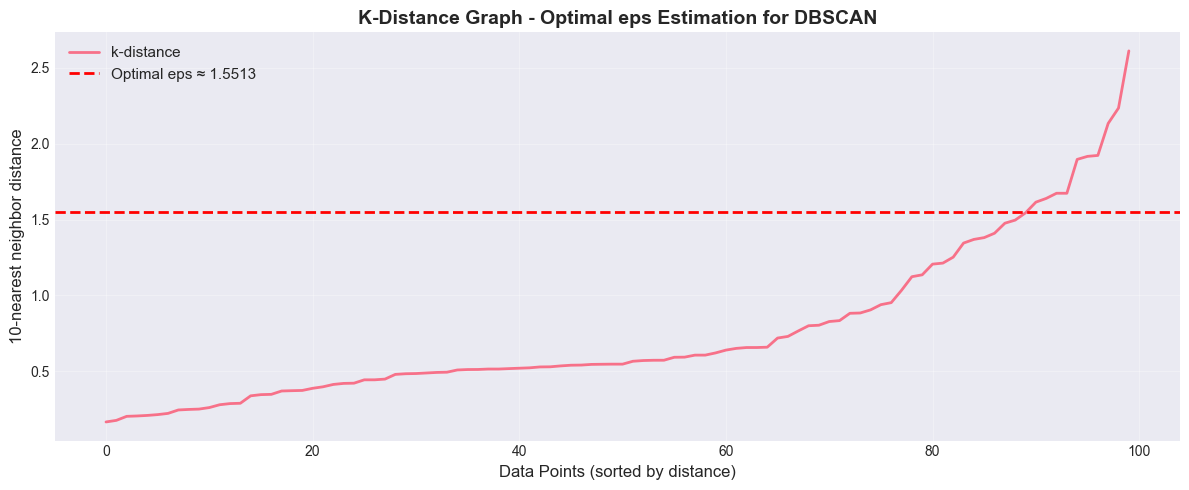

In [32]:
# Find optimal eps
eps_optimal, distances = estimate_optimal_eps(scaled_clustering, min_samples=10, plot=True)



In [33]:
# ============================================================================
# CELL 5: DBSCAN PARAMETER SENSITIVITY ANALYSIS
# ============================================================================

def dbscan_parameter_sensitivity(scaled_data, eps_range=None, min_samples_range=None):
    """
    Test DBSCAN across parameter ranges.
    """
    
    print(f"\n{'='*70}")
    print("DBSCAN PARAMETER SENSITIVITY ANALYSIS")
    print(f"{'='*70}")
    
    if eps_range is None:
        eps_range = np.round(np.linspace(0.1, 1.0, 10), 3)
    if min_samples_range is None:
        min_samples_range = [5, 10, 15]
    
    results = []
    
    for eps in eps_range:
        for min_samp in min_samples_range:
            dbscan_test = DBSCAN(eps=eps, min_samples=min_samp)
            labels = dbscan_test.fit_predict(scaled_data)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = np.sum(labels == -1)
            noise_pct = 100 * n_noise / len(labels)
            
            if n_clusters > 0 and np.sum(labels != -1) > 1:
                valid_mask = labels != -1
                try:
                    sil_score = silhouette_score(scaled_data[valid_mask], labels[valid_mask])
                except:
                    sil_score = np.nan
            else:
                sil_score = np.nan
            
            results.append({
                'eps': eps,
                'min_samples': min_samp,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': noise_pct,
                'silhouette': sil_score
            })
    
    results_df = pd.DataFrame(results)
    
    print("\n" + "="*100)
    print("Parameter Search Results (sorted by Silhouette Score):")
    print("="*100)
    print(results_df.sort_values('silhouette', ascending=False, na_position='last').to_string(index=False))
    
    # Find best parameters
    valid_results = results_df[
        (results_df['n_clusters'] > 1) & 
        (results_df['noise_pct'] < 50) &
        (~results_df['silhouette'].isna())
    ]
    
    if len(valid_results) > 0:
        best_idx = valid_results['silhouette'].idxmax()
        best_eps = results_df.loc[best_idx, 'eps']
        best_min_samp = results_df.loc[best_idx, 'min_samples']
        best_sil = results_df.loc[best_idx, 'silhouette']
        
        print(f"\n🏆 BEST PARAMETERS (by Silhouette Score):")
        print(f"   eps: {best_eps:.4f}")
        print(f"   min_samples: {int(best_min_samp)}")
        print(f"   Silhouette Score: {best_sil:.4f}")
        print(f"   Clusters: {int(results_df.loc[best_idx, 'n_clusters'])}")
        print(f"   Noise: {results_df.loc[best_idx, 'noise_pct']:.1f}%")
        
        return best_eps, int(best_min_samp), results_df
    else:
        print("⚠️ No valid parameter combinations found. Using default values.")
        return eps_optimal, 10, results_df


best_eps, best_min_samp, sensitivity_results = dbscan_parameter_sensitivity(
    scaled_clustering,
    eps_range=np.linspace(eps_optimal * 0.5, eps_optimal * 2.0, 8),
    min_samples_range=[5, 10, 15]
)




DBSCAN PARAMETER SENSITIVITY ANALYSIS

Parameter Search Results (sorted by Silhouette Score):
     eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
0.775674           10           5       19       19.0    0.644150
0.775674           15           3       49       49.0    0.622369
0.775674            5           5       12       12.0    0.586313
1.108106           15           3       14       14.0    0.426544
1.108106           10           3       11       11.0    0.413012
1.440538           15           3        7        7.0    0.387868
1.108106            5           3        5        5.0    0.387239
1.440538           10           3        4        4.0    0.378042
1.440538            5           3        1        1.0    0.370123
1.772969            5           1        1        1.0         NaN
1.772969           10           1        1        1.0         NaN
1.772969           15           1        2        2.0         NaN
2.105401            5           1        0     

In [34]:
# ============================================================================
# CELL 6: CLUSTERING COMPARISON (K-MEANS vs IMPROVED DBSCAN)
# ============================================================================

def perform_clustering(scaled_data, original_data, eps, min_samples, n_clusters_kmeans=5):
    """
    Perform both K-Means and DBSCAN clustering with evaluation.
    """
    
    print(f"\n{'='*70}")
    print("CLUSTERING: K-MEANS vs DBSCAN")
    print(f"{'='*70}")
    
    # K-Means
    print(f"\n--- K-MEANS (n_clusters={n_clusters_kmeans}) ---")
    kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(scaled_data)
    
    kmeans_silhouette = silhouette_score(scaled_data, kmeans_labels)
    kmeans_davies = davies_bouldin_score(scaled_data, kmeans_labels)
    kmeans_ch = calinski_harabasz_score(scaled_data, kmeans_labels)
    
    print(f"Silhouette Score: {kmeans_silhouette:.4f} (range: -1 to 1; higher is better)")
    print(f"Davies-Bouldin Index: {kmeans_davies:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {kmeans_ch:.1f} (higher is better)")
    print(f"Clusters: {n_clusters_kmeans}")
    
    # DBSCAN (improved)
    print(f"\n--- DBSCAN (eps={eps:.4f}, min_samples={min_samples}) ---")
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(scaled_data)
    
    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = np.sum(dbscan_labels == -1)
    noise_pct = 100 * n_noise / len(dbscan_labels)
    
    valid_mask = dbscan_labels != -1
    if np.sum(valid_mask) > 1:
        dbscan_silhouette = silhouette_score(scaled_data[valid_mask], dbscan_labels[valid_mask])
        dbscan_davies = davies_bouldin_score(scaled_data[valid_mask], dbscan_labels[valid_mask])
        dbscan_ch = calinski_harabasz_score(scaled_data[valid_mask], dbscan_labels[valid_mask])
    else:
        dbscan_silhouette = dbscan_davies = dbscan_ch = np.nan
    
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {dbscan_davies:.4f}")
    print(f"Calinski-Harabasz Score: {dbscan_ch:.1f}")
    print(f"Clusters found: {n_clusters_dbscan}")
    print(f"Noise points: {n_noise} ({noise_pct:.1f}%)")
    
    # Comparison
    print(f"\n{'='*70}")
    print("COMPARISON SUMMARY")
    print(f"{'='*70}")
    print(f"{'Metric':<30} {'K-Means':>15} {'DBSCAN':>15} {'Better':>15}")
    print(f"{'-'*75}")
    print(f"{'Silhouette Score':<30} {kmeans_silhouette:>15.4f} {dbscan_silhouette:>15.4f} "
          f"{'DBSCAN' if dbscan_silhouette > kmeans_silhouette else 'K-Means':>15}")
    print(f"{'Davies-Bouldin Index':<30} {kmeans_davies:>15.4f} {dbscan_davies:>15.4f} "
          f"{'DBSCAN' if dbscan_davies < kmeans_davies else 'K-Means':>15}")
    print(f"{'Calinski-Harabasz Score':<30} {kmeans_ch:>15.1f} {dbscan_ch:>15.1f} "
          f"{'DBSCAN' if dbscan_ch > kmeans_ch else 'K-Means':>15}")
    
    return {
        'kmeans': {'model': kmeans, 'labels': kmeans_labels, 'silhouette': kmeans_silhouette},
        'dbscan': {'model': dbscan, 'labels': dbscan_labels, 'silhouette': dbscan_silhouette}
    }


clustering_results = perform_clustering(
    scaled_clustering, clustering_data, 
    eps=best_eps, min_samples=best_min_samp, 
    n_clusters_kmeans=5
)



CLUSTERING: K-MEANS vs DBSCAN

--- K-MEANS (n_clusters=5) ---
Silhouette Score: 0.5075 (range: -1 to 1; higher is better)
Davies-Bouldin Index: 0.7506 (lower is better)
Calinski-Harabasz Score: 75.6 (higher is better)
Clusters: 5

--- DBSCAN (eps=0.7757, min_samples=10) ---
Silhouette Score: 0.6442
Davies-Bouldin Index: 0.5064
Calinski-Harabasz Score: 170.5
Clusters found: 5
Noise points: 19 (19.0%)

COMPARISON SUMMARY
Metric                                 K-Means          DBSCAN          Better
---------------------------------------------------------------------------
Silhouette Score                        0.5075          0.6442          DBSCAN
Davies-Bouldin Index                    0.7506          0.5064          DBSCAN
Calinski-Harabasz Score                   75.6           170.5          DBSCAN



VISUALIZING CLUSTERING RESULTS


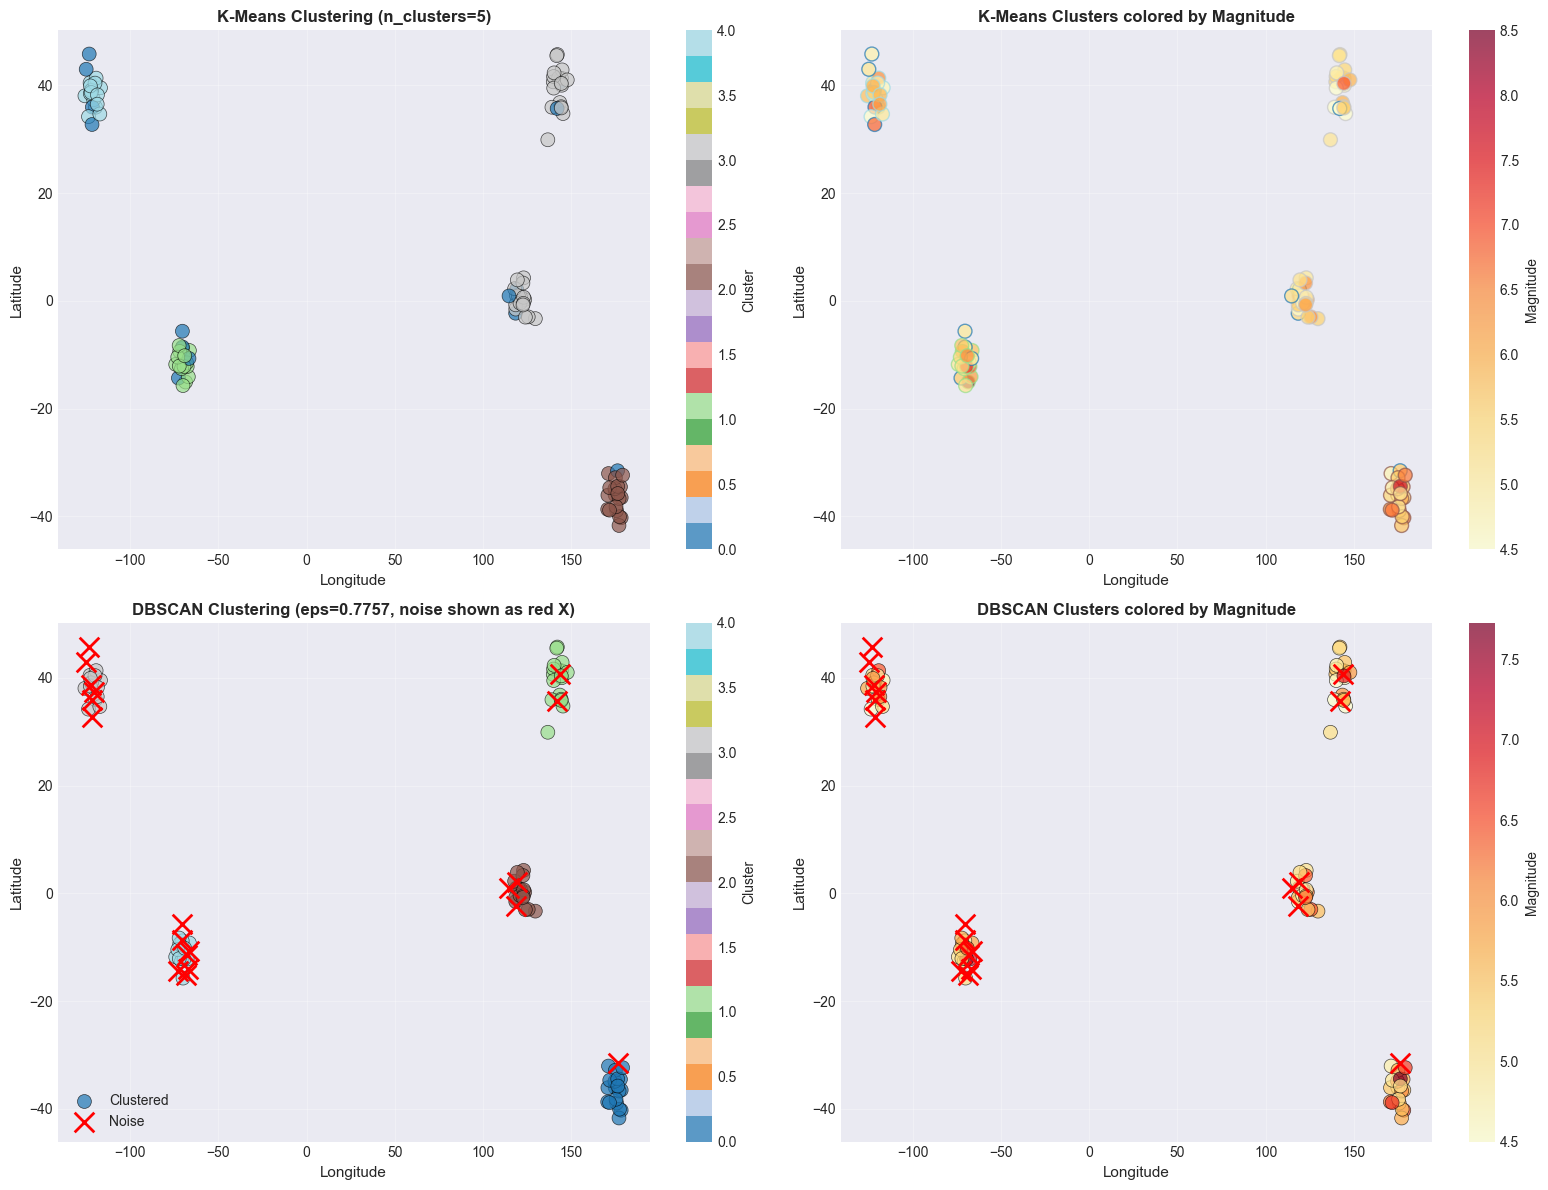


✅ Clustering visualization complete


In [36]:

# ============================================================================
# CELL 7: VISUALIZE CLUSTERING RESULTS
# ============================================================================

def visualize_clustering(original_data, clustering_results):
    """
    Visualize clustering results on maps.
    """
    
    print(f"\n{'='*70}")
    print("VISUALIZING CLUSTERING RESULTS")
    print(f"{'='*70}")
    
    kmeans_labels = clustering_results['kmeans']['labels']
    dbscan_labels = clustering_results['dbscan']['labels']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # K-Means plot
    ax = axes[0, 0]
    scatter = ax.scatter(original_data['Longitude'], original_data['Latitude'],
                        c=kmeans_labels, cmap='tab20', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title('K-Means Clustering (n_clusters=5)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    ax.grid(True, alpha=0.3)
    
    # K-Means with magnitude
    ax = axes[0, 1]
    scatter = ax.scatter(original_data['Longitude'], original_data['Latitude'],
                        c=original_data['Mag'], s=100, alpha=0.7, 
                        edgecolors=plt.cm.tab20(kmeans_labels.astype(float) / kmeans_labels.max()),
                        linewidth=1, cmap='YlOrRd')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title('K-Means Clusters colored by Magnitude', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Magnitude')
    ax.grid(True, alpha=0.3)
    
    # DBSCAN plot
    ax = axes[1, 0]
    clustered_mask = dbscan_labels != -1
    noise_mask = dbscan_labels == -1
    
    scatter1 = ax.scatter(original_data[clustered_mask]['Longitude'],
                         original_data[clustered_mask]['Latitude'],
                         c=dbscan_labels[clustered_mask], cmap='tab20',
                         s=100, alpha=0.7, edgecolors='black', linewidth=0.5, label='Clustered')
    if np.sum(noise_mask) > 0:
        ax.scatter(original_data[noise_mask]['Longitude'],
                  original_data[noise_mask]['Latitude'],
                  c='red', marker='x', s=200, linewidths=2, label='Noise')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title(f'DBSCAN Clustering (eps={best_eps:.4f}, noise shown as red X)',
                fontsize=12, fontweight='bold')
    plt.colorbar(scatter1, ax=ax, label='Cluster')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # DBSCAN with magnitude
    ax = axes[1, 1]
    scatter = ax.scatter(original_data[clustered_mask]['Longitude'],
                        original_data[clustered_mask]['Latitude'],
                        c=original_data[clustered_mask]['Mag'],
                        s=100, alpha=0.7, edgecolors='black', linewidth=0.5, cmap='YlOrRd')
    if np.sum(noise_mask) > 0:
        ax.scatter(original_data[noise_mask]['Longitude'],
                  original_data[noise_mask]['Latitude'],
                  c='red', marker='x', s=200, linewidths=2)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title('DBSCAN Clusters colored by Magnitude', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Magnitude')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Clustering visualization complete")


# ✅ CORRECT (df_processed has all columns including 'Mag')
visualize_clustering(df_processed.reset_index(drop=True), clustering_results)




ML RISK CLASSIFICATION (with SMOTE Balancing)

Features: ['Latitude', 'Longitude', 'Depth', 'Hour', 'DayOfYear']
Target: Risk_Category (0=Low, 1=Moderate, 2=High)
Data shape: (100, 5)

Train set: 80 | Test set: 20

Applying SMOTE to training data...
Before SMOTE: 80
After SMOTE: 120

----------------------------------------------------------------------
RANDOM FOREST CLASSIFIER
----------------------------------------------------------------------
Accuracy: 0.2000
F1 Score (weighted): 0.2231

Confusion Matrix:
[[3 5 2]
 [3 1 3]
 [1 2 0]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.43      0.30      0.35        10
    Moderate       0.12      0.14      0.13         7
        High       0.00      0.00      0.00         3

    accuracy                           0.20        20
   macro avg       0.18      0.15      0.16        20
weighted avg       0.26      0.20      0.22        20


-------------------------------------------------

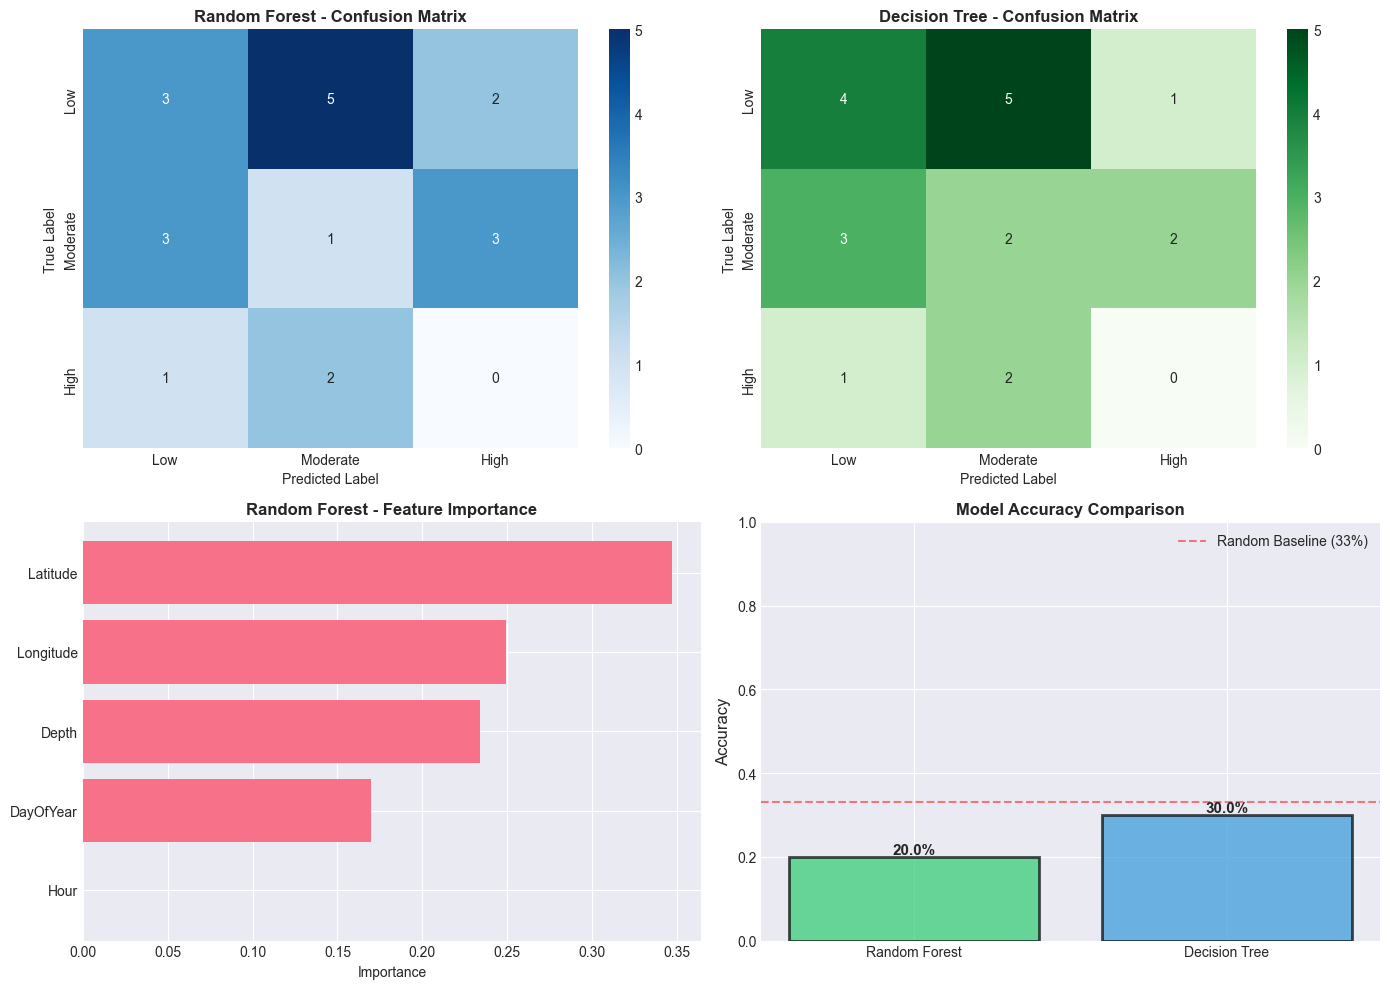


✅ ML visualization complete


In [37]:
# ============================================================================
# CELL 8: ML RISK CLASSIFICATION WITH PROPER SMOTE
# ============================================================================

def train_ml_models(df_processed):
    """
    Train Random Forest and Decision Tree with SMOTE balancing.
    """
    
    print(f"\n{'='*70}")
    print("ML RISK CLASSIFICATION (with SMOTE Balancing)")
    print(f"{'='*70}")
    
    # Prepare features (NO Magnitude to avoid leakage)
    feature_columns = ['Latitude', 'Longitude', 'Depth', 'Hour', 'DayOfYear']
    X = df_processed[feature_columns].dropna()
    y = df_processed.loc[X.index, 'Risk_Category']
    
    print(f"\nFeatures: {feature_columns}")
    print(f"Target: Risk_Category (0=Low, 1=Moderate, 2=High)")
    print(f"Data shape: {X.shape}")
    
    # Train-test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTrain set: {len(X_train)} | Test set: {len(X_test)}")
    
    # Apply SMOTE to training data only
    print(f"\nApplying SMOTE to training data...")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    print(f"Before SMOTE: {len(X_train)}")
    print(f"After SMOTE: {len(X_train_balanced)}")
    
    # Standardize features
    scaler_ml = StandardScaler()
    X_train_scaled = scaler_ml.fit_transform(X_train_balanced)
    X_test_scaled = scaler_ml.transform(X_test)
    
    # ===== Random Forest =====
    print(f"\n{'-'*70}")
    print("RANDOM FOREST CLASSIFIER")
    print(f"{'-'*70}")
    
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_scaled, y_train_balanced)
    rf_pred = rf_model.predict(X_test_scaled)
    rf_pred_proba = rf_model.predict_proba(X_test_scaled)
    
    rf_accuracy = accuracy_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred, average='weighted')
    
    print(f"Accuracy: {rf_accuracy:.4f}")
    print(f"F1 Score (weighted): {rf_f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, rf_pred))
    print(f"\nClassification Report:")
    print(classification_report(y_test, rf_pred, 
                              target_names=['Low', 'Moderate', 'High']))
    
    # ===== Decision Tree =====
    print(f"\n{'-'*70}")
    print("DECISION TREE CLASSIFIER")
    print(f"{'-'*70}")
    
    dt_model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        criterion='entropy',
        class_weight='balanced',
        random_state=42
    )
    
    dt_model.fit(X_train_scaled, y_train_balanced)
    dt_pred = dt_model.predict(X_test_scaled)
    
    dt_accuracy = accuracy_score(y_test, dt_pred)
    dt_f1 = f1_score(y_test, dt_pred, average='weighted')
    
    print(f"Accuracy: {dt_accuracy:.4f}")
    print(f"F1 Score (weighted): {dt_f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, dt_pred))
    print(f"\nClassification Report:")
    print(classification_report(y_test, dt_pred,
                              target_names=['Low', 'Moderate', 'High']))
    
    # ===== Model Comparison =====
    print(f"\n{'='*70}")
    print("MODEL COMPARISON")
    print(f"{'='*70}")
    print(f"{'Metric':<30} {'Random Forest':>20} {'Decision Tree':>20}")
    print(f"{'-'*70}")
    print(f"{'Accuracy':<30} {rf_accuracy:>20.4f} {dt_accuracy:>20.4f}")
    print(f"{'F1 Score (weighted)':<30} {rf_f1:>20.4f} {dt_f1:>20.4f}")
    
    if rf_accuracy > dt_accuracy:
        print(f"\n🏆 Random Forest is the better model")
    else:
        print(f"\n🏆 Decision Tree is the better model")
    
    return {
        'rf': {
            'model': rf_model,
            'scaler': scaler_ml,
            'accuracy': rf_accuracy,
            'f1': rf_f1,
            'pred': rf_pred,
            'pred_proba': rf_pred_proba
        },
        'dt': {
            'model': dt_model,
            'scaler': scaler_ml,
            'accuracy': dt_accuracy,
            'f1': dt_f1,
            'pred': dt_pred
        },
        'X_test': X_test_scaled,
        'y_test': y_test,
        'feature_names': feature_columns
    }


ml_results = train_ml_models(df_processed)


# ============================================================================
# CELL 9: ML MODEL VISUALIZATIONS
# ============================================================================

def visualize_ml_results(ml_results):
    """
    Visualize ML classification results.
    """
    
    print(f"\n{'='*70}")
    print("ML RESULTS VISUALIZATION")
    print(f"{'='*70}")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Confusion matrix - Random Forest
    cm_rf = confusion_matrix(ml_results['y_test'], ml_results['rf']['pred'])
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
               xticklabels=['Low', 'Moderate', 'High'],
               yticklabels=['Low', 'Moderate', 'High'])
    axes[0, 0].set_title('Random Forest - Confusion Matrix', fontweight='bold')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')
    
    # Confusion matrix - Decision Tree
    cm_dt = confusion_matrix(ml_results['y_test'], ml_results['dt']['pred'])
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
               xticklabels=['Low', 'Moderate', 'High'],
               yticklabels=['Low', 'Moderate', 'High'])
    axes[0, 1].set_title('Decision Tree - Confusion Matrix', fontweight='bold')
    axes[0, 1].set_ylabel('True Label')
    axes[0, 1].set_xlabel('Predicted Label')
    
    # Feature importance - Random Forest
    feature_names = ml_results['feature_names']
    importances = ml_results['rf']['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    axes[1, 0].barh(range(len(indices)), importances[indices], align='center')
    axes[1, 0].set_yticks(range(len(indices)))
    axes[1, 0].set_yticklabels([feature_names[i] for i in indices])
    axes[1, 0].set_xlabel('Importance')
    axes[1, 0].set_title('Random Forest - Feature Importance', fontweight='bold')
    axes[1, 0].invert_yaxis()
    
    # Model accuracy comparison
    models = ['Random Forest', 'Decision Tree']
    accuracies = [ml_results['rf']['accuracy'], ml_results['dt']['accuracy']]
    colors = ['#2ecc71', '#3498db']
    
    bars = axes[1, 1].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[1, 1].set_ylabel('Accuracy', fontsize=12)
    axes[1, 1].set_title('Model Accuracy Comparison', fontweight='bold')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].axhline(y=0.33, color='red', linestyle='--', alpha=0.5, label='Random Baseline (33%)')
    axes[1, 1].legend()
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{acc:.1%}',
                       ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ ML visualization complete")


visualize_ml_results(ml_results)


DECISION TREE RULES

Decision Tree Rules (Text Format):
|--- Latitude <= 1.11
|   |--- Latitude <= -1.41
|   |   |--- Longitude <= 1.10
|   |   |   |--- class: 1
|   |   |--- Longitude >  1.10
|   |   |   |--- class: 1
|   |--- Latitude >  -1.41
|   |   |--- Depth <= -0.66
|   |   |   |--- DayOfYear <= -1.19
|   |   |   |   |--- class: 1
|   |   |   |--- DayOfYear >  -1.19
|   |   |   |   |--- Depth <= -0.72
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Depth >  -0.72
|   |   |   |   |   |--- class: 1
|   |   |--- Depth >  -0.66
|   |   |   |--- Latitude <= -0.24
|   |   |   |   |--- DayOfYear <= 0.13
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- DayOfYear >  0.13
|   |   |   |   |   |--- class: 2
|   |   |   |--- Latitude >  -0.24
|   |   |   |   |--- Longitude <= -0.00
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Longitude >  -0.00
|   |   |   |   |   |--- class: 0
|--- Latitude >  1.11
|   |--- DayOfYear <= 1.46
|   |   |--- DayOfYear <= -0.15
|   |   | 

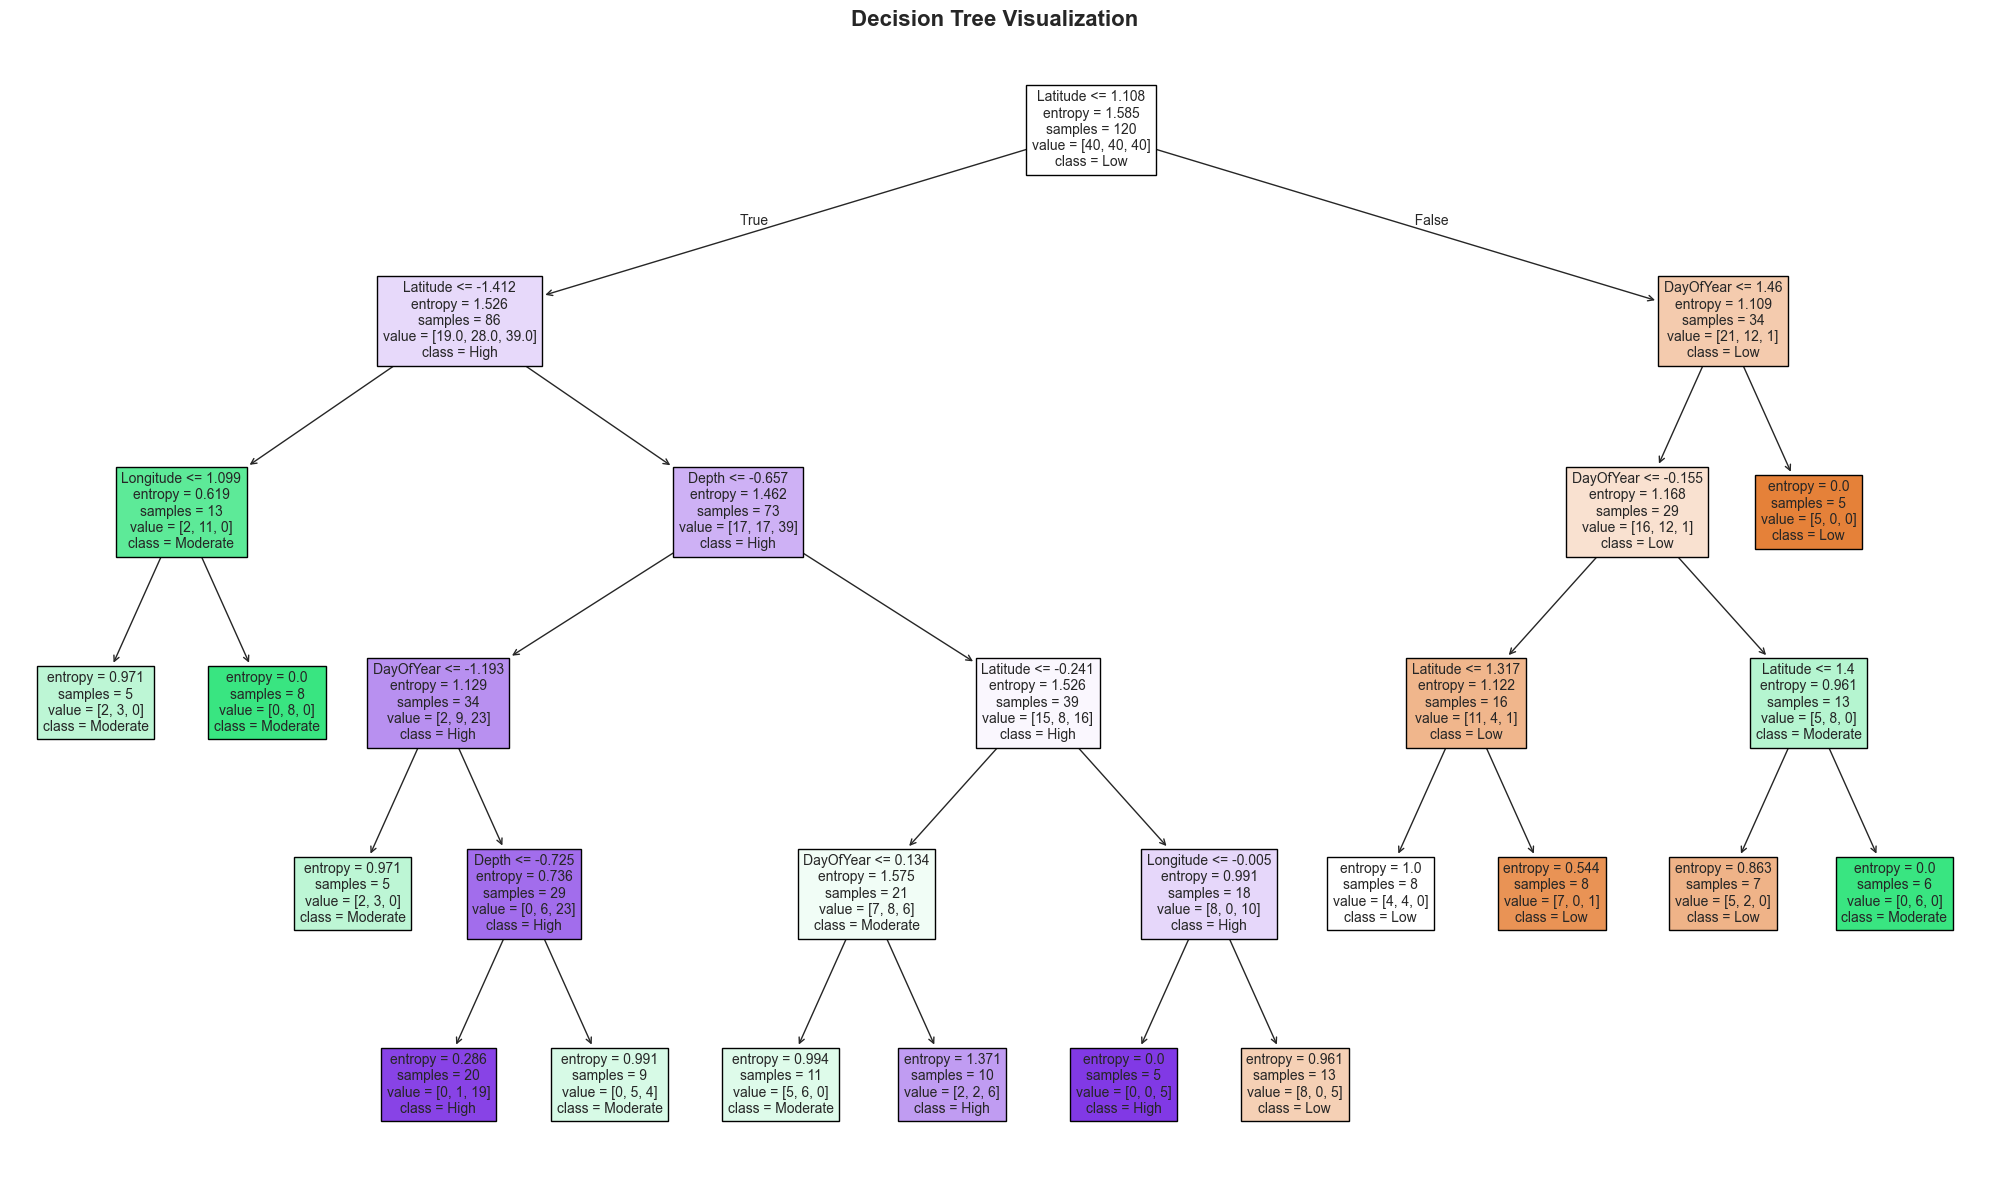


✅ Decision tree rules extracted


In [38]:
# ============================================================================
# CELL 10: DECISION TREE RULES EXTRACTION
# ============================================================================

def extract_decision_tree_rules(ml_results):
    """
    Extract and display decision tree rules.
    """
    
    print(f"\n{'='*70}")
    print("DECISION TREE RULES")
    print(f"{'='*70}")
    
    dt_model = ml_results['dt']['model']
    feature_names = ml_results['feature_names']
    
    # Export text rules
    rules_text = export_text(dt_model, feature_names=feature_names)
    print("\nDecision Tree Rules (Text Format):")
    print("="*70)
    print(rules_text)
    
    # Visualize tree
    fig, ax = plt.subplots(figsize=(20, 12))
    plot_tree(dt_model,
             feature_names=feature_names,
             class_names=['Low', 'Moderate', 'High'],
             filled=True,
             ax=ax,
             fontsize=10)
    plt.title('Decision Tree Visualization', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Decision tree rules extracted")


extract_decision_tree_rules(ml_results)


In [39]:

# ============================================================================
# CELL 11: LIVE INTERACTIVE EARTHQUAKE MAP (FOLIUM)
# ============================================================================

def create_interactive_earthquake_map(df_processed):
    """
    Create interactive Folium map with earthquakes and heatmap.
    """
    
    print(f"\n{'='*70}")
    print("CREATING INTERACTIVE EARTHQUAKE MAP")
    print(f"{'='*70}")
    
    # Color function for risk severity
    def get_risk_color(risk_category):
        colors = {0: 'green', 1: 'orange', 2: 'red'}  # Low, Moderate, High
        return colors.get(risk_category, 'gray')
    
    def get_risk_name(risk_category):
        names = {0: 'Low', 1: 'Moderate', 2: 'High'}
        return names.get(risk_category, 'Unknown')
    
    # Create base map (centered on Pacific Ring of Fire)
    m = folium.Map(location=[0, -120], zoom_start=2, tiles='OpenStreetMap')
    
    # Add marker cluster group
    marker_cluster = MarkerCluster().add_to(m)
    
    # Add individual markers with risk colors
    for idx, row in df_processed.iterrows():
        # Create popup with earthquake details
        popup_text = f"""
        <b>{row['Place']}</b><br>
        Magnitude: {row['Mag']:.1f}<br>
        Depth: {row['Depth']:.1f} km<br>
        Risk: <span style="color:{get_risk_color(row['Risk_Category'])};"><b>{get_risk_name(row['Risk_Category'])}</b></span><br>
        Time: {row['Time'].strftime('%Y-%m-%d %H:%M:%S')}<br>
        Lat: {row['Latitude']:.2f}°<br>
        Lon: {row['Longitude']:.2f}°
        """
        
        folium.CircleMarker(
            location=(row['Latitude'], row['Longitude']),
            radius=5 + row['Mag'],  # Size proportional to magnitude
            popup=folium.Popup(popup_text, max_width=250),
            color=get_risk_color(row['Risk_Category']),
            fill=True,
            fillColor=get_risk_color(row['Risk_Category']),
            fillOpacity=0.7,
            weight=2
        ).add_to(m)
    
    # Add heatmap layer
    heat_data = [[row['Latitude'], row['Longitude'], row['Mag']/10] 
                 for idx, row in df_processed.iterrows()]
    HeatMap(heat_data, radius=15, blur=15, max_zoom=1).add_to(m)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 200px; height: 180px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
                <p style="margin: 0;"><b>Earthquake Risk Legend</b></p>
                <p style="margin: 5px 0;"><i class="fa fa-circle" style="color:green"></i> Low Risk (M < 5.5)</p>
                <p style="margin: 5px 0;"><i class="fa fa-circle" style="color:orange"></i> Moderate Risk (5.5 ≤ M < 6.5)</p>
                <p style="margin: 5px 0;"><i class="fa fa-circle" style="color:red"></i> High Risk (M ≥ 6.5)</p>
                <p style="margin: 10px 0;"><small>Marker size = Magnitude</small></p>
                <p style="margin: 0;"><small>Last updated: {}</small></p>
    </div>
    '''.format(datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC'))
    
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Save map
    map_file = 'earthquake_tracker_map.html'
    m.save(map_file)
    print(f"\n✅ Interactive map saved as '{map_file}'")
    
    return m


earthquake_map = create_interactive_earthquake_map(df_processed)
print("📍 Open 'earthquake_tracker_map.html' in your browser to view the interactive map")




CREATING INTERACTIVE EARTHQUAKE MAP

✅ Interactive map saved as 'earthquake_tracker_map.html'
📍 Open 'earthquake_tracker_map.html' in your browser to view the interactive map



STATISTICAL SUMMARY & INSIGHTS

📊 MAGNITUDE STATISTICS:
  Mean: 5.59
  Median: 5.50
  Std Dev: 0.78
  Min: 4.50
  Max: 8.50

📊 DEPTH STATISTICS:
  Mean: 53.10 km
  Median: 33.13 km
  Std Dev: 48.45 km
  Max: 217.20 km

📊 TEMPORAL DISTRIBUTION:
  Total events: 100
  Date range: 2026-02-06 to 2026-03-07
  Events per day (average): 3.45

📊 LOCATION HOTSPOTS (Top 5):
  South America: 20 events
  New Zealand: 20 events
  Japan: 20 events
  Indonesia: 20 events
  San Francisco: 20 events

📊 DEPTH CATEGORY DISTRIBUTION:
  Shallow:   62 ( 62.0%)
  Intermediate:   22 ( 22.0%)
  Deep:   16 ( 16.0%)
  Very Deep:    0 (  0.0%)

📊 HOURLY DISTRIBUTION (all hours):
  Peak hour: 12:00 UTC (100 events)
  Quiet hour: 12:00 UTC (100 events)


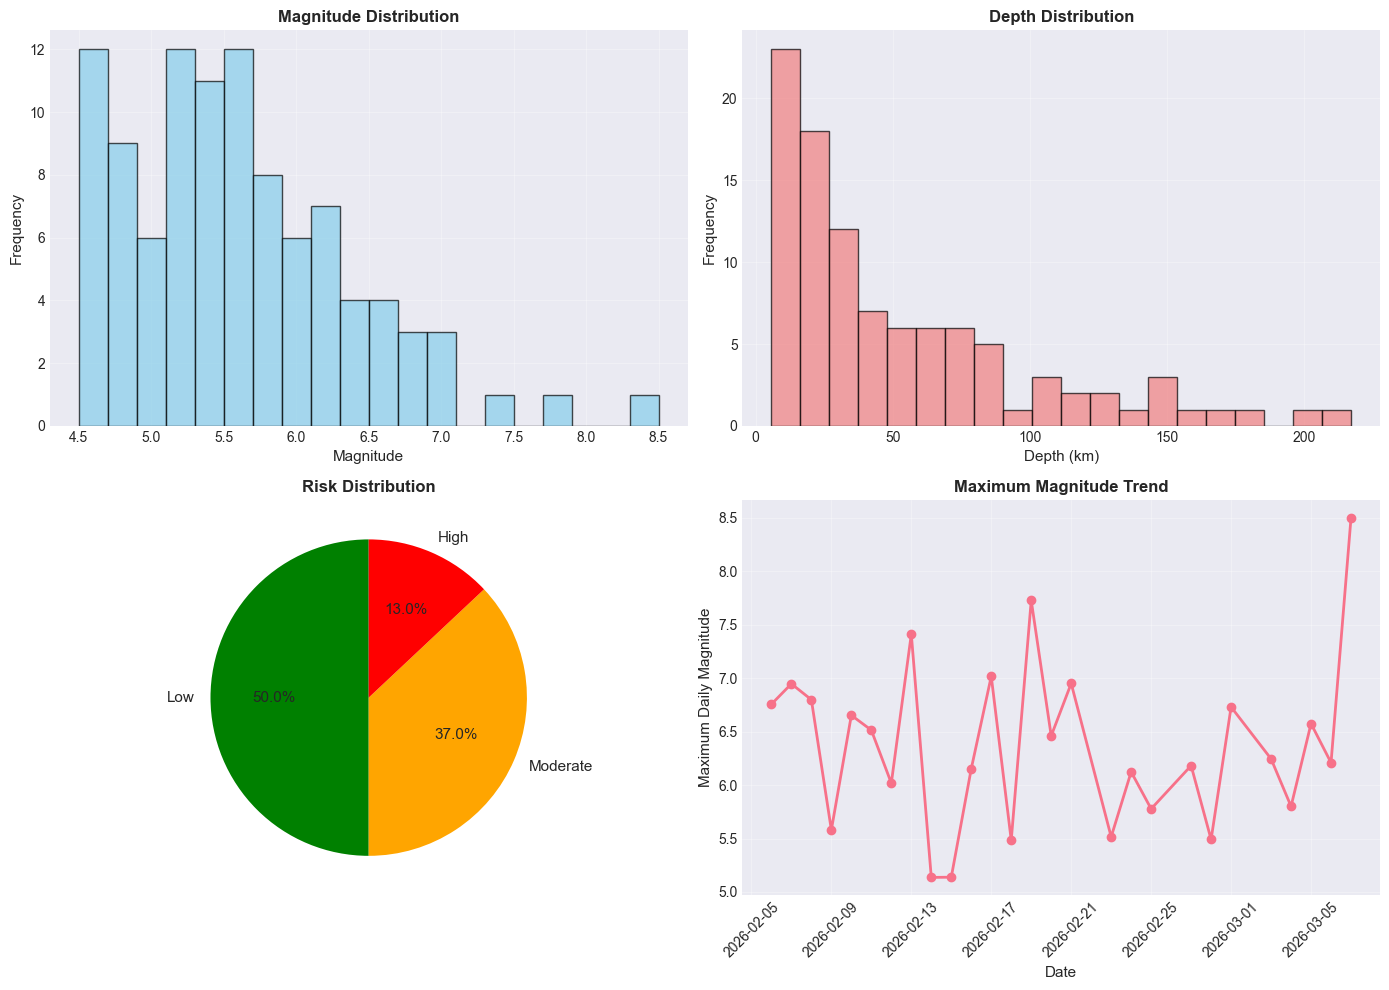


✅ Statistical summary complete


In [40]:

# ============================================================================
# CELL 12: STATISTICAL SUMMARY & INSIGHTS
# ============================================================================

def generate_statistical_summary(df_processed):
    """
    Generate comprehensive statistical summary.
    """
    
    print(f"\n{'='*70}")
    print("STATISTICAL SUMMARY & INSIGHTS")
    print(f"{'='*70}")
    
    # Basic statistics
    print(f"\n📊 MAGNITUDE STATISTICS:")
    print(f"  Mean: {df_processed['Mag'].mean():.2f}")
    print(f"  Median: {df_processed['Mag'].median():.2f}")
    print(f"  Std Dev: {df_processed['Mag'].std():.2f}")
    print(f"  Min: {df_processed['Mag'].min():.2f}")
    print(f"  Max: {df_processed['Mag'].max():.2f}")
    
    print(f"\n📊 DEPTH STATISTICS:")
    print(f"  Mean: {df_processed['Depth'].mean():.2f} km")
    print(f"  Median: {df_processed['Depth'].median():.2f} km")
    print(f"  Std Dev: {df_processed['Depth'].std():.2f} km")
    print(f"  Max: {df_processed['Depth'].max():.2f} km")
    
    print(f"\n📊 TEMPORAL DISTRIBUTION:")
    print(f"  Total events: {len(df_processed)}")
    print(f"  Date range: {df_processed['Time'].min().date()} to {df_processed['Time'].max().date()}")
    print(f"  Events per day (average): {len(df_processed) / (df_processed['Time'].max() - df_processed['Time'].min()).days:.2f}")
    
    print(f"\n📊 LOCATION HOTSPOTS (Top 5):")
    top_places = df_processed['Place'].value_counts().head(5)
    for place, count in top_places.items():
        print(f"  {place}: {count} events")
    
    print(f"\n📊 DEPTH CATEGORY DISTRIBUTION:")
    depth_dist = df_processed['Depth_Category'].value_counts().sort_index()
    for depth_cat, count in depth_dist.items():
        pct = 100 * count / len(df_processed)
        print(f"  {depth_cat}: {count:4d} ({pct:5.1f}%)")
    
    # Hourly distribution
    print(f"\n📊 HOURLY DISTRIBUTION (all hours):")
    hourly = df_processed['Hour'].value_counts().sort_index()
    print(f"  Peak hour: {hourly.idxmax()}:00 UTC ({hourly.max()} events)")
    print(f"  Quiet hour: {hourly.idxmin()}:00 UTC ({hourly.min()} events)")
    
    # Magnitude distribution visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Magnitude histogram
    axes[0, 0].hist(df_processed['Mag'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Magnitude', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Magnitude Distribution', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Depth histogram
    axes[0, 1].hist(df_processed['Depth'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Depth (km)', fontsize=11)
    axes[0, 1].set_ylabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Depth Distribution', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Risk category pie chart
    risk_counts = df_processed['Risk_Category'].value_counts()
    risk_names = {0: 'Low', 1: 'Moderate', 2: 'High'}
    labels = [risk_names[i] for i in risk_counts.index]
    colors = ['green', 'orange', 'red']
    
    axes[1, 0].pie(risk_counts, labels=labels, colors=colors, autopct='%1.1f%%',
                  startangle=90, textprops={'fontsize': 11})
    axes[1, 0].set_title('Risk Distribution', fontweight='bold')
    
    # Time series - magnitude over time
    daily_mag = df_processed.groupby(df_processed['Time'].dt.date)['Mag'].max()
    axes[1, 1].plot(daily_mag.index, daily_mag.values, marker='o', linestyle='-', linewidth=2, markersize=6)
    axes[1, 1].set_xlabel('Date', fontsize=11)
    axes[1, 1].set_ylabel('Maximum Daily Magnitude', fontsize=11)
    axes[1, 1].set_title('Maximum Magnitude Trend', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Statistical summary complete")


generate_statistical_summary(df_processed)




TIME SERIES FORECASTING - AVERAGE MAGNITUDE

Daily magnitude time series:
  Observations: 27
  Mean: 5.56
  Std: 0.32

Stationarity Test (ADF):
  p-value: 0.0003
  ✅ Time series is stationary (differencing not needed)

Fitting ARIMA(1,0,1) model...
✅ Model fitted successfully


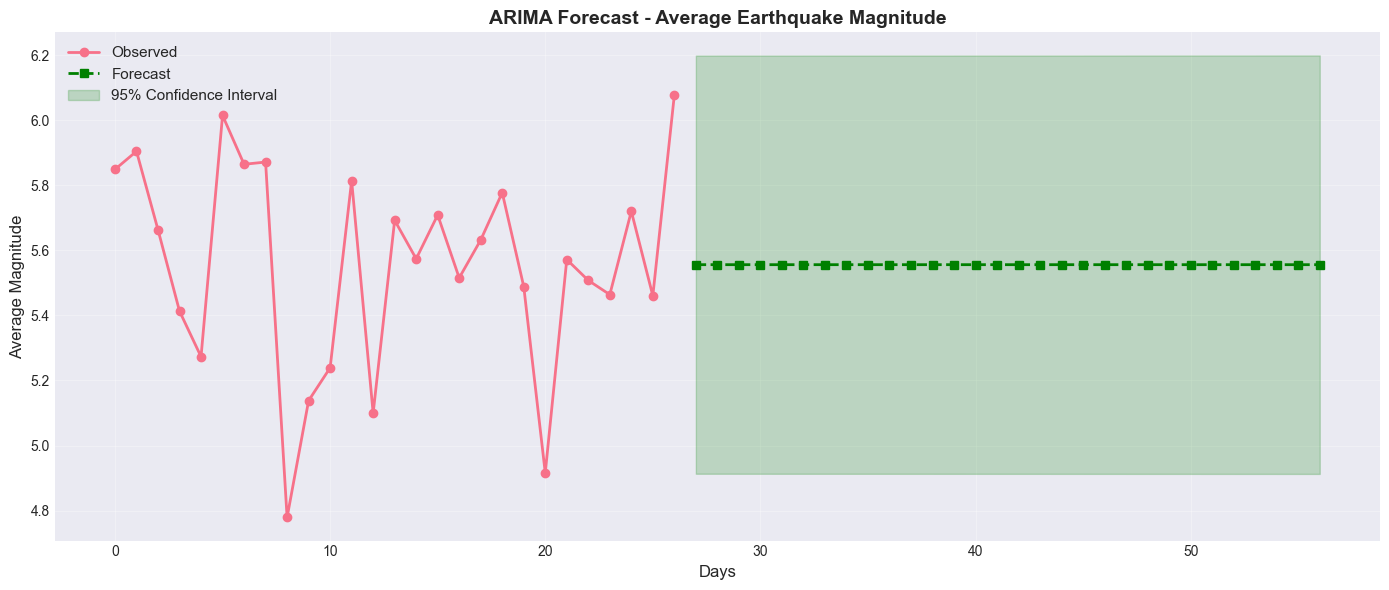


✅ Forecast generated for next 30 days

Forecast Summary:
  Expected avg magnitude (next 30 days): 5.56
  Forecast range: 4.91 to 6.20


In [45]:
# ============================================================================
# CELL 13: TIME SERIES FORECASTING (ARIMA)
# ============================================================================

def forecast_earthquake_activity(df_processed, forecast_steps=30):
    """
    Forecast future earthquake activity using ARIMA.
    """
    
    print(f"\n{'='*70}")
    print("TIME SERIES FORECASTING - AVERAGE MAGNITUDE")
    print(f"{'='*70}")
    
    # Prepare daily average magnitude
    daily_mag = df_processed.groupby(df_processed['Time'].dt.date)['Mag'].mean()
    
    if len(daily_mag) < 10:
        print("⚠️ Insufficient data for time series modeling (need at least 10 observations)")
        return None
    
    print(f"\nDaily magnitude time series:")
    print(f"  Observations: {len(daily_mag)}")
    print(f"  Mean: {daily_mag.mean():.2f}")
    print(f"  Std: {daily_mag.std():.2f}")
    
    # Check stationarity
    adf_result = adfuller(daily_mag, autolag='AIC')
    print(f"\nStationarity Test (ADF):")
    print(f"  p-value: {adf_result[1]:.4f}")
    if adf_result[1] < 0.05:
        print(f"  ✅ Time series is stationary (differencing not needed)")
        d = 0
    else:
        print(f"  ⚠️ Time series is non-stationary (differencing recommended)")
        d = 1
    
    try:
        # Fit ARIMA model
        print(f"\nFitting ARIMA({1},{d},{1}) model...")
        model = SARIMAX(daily_mag, order=(1, d, 1), seasonal_order=(0, 0, 0, 0))
        results = model.fit(disp=False)
        
        print(f"✅ Model fitted successfully")
        
        # Forecast
        forecast = results.get_forecast(steps=forecast_steps)
        forecast_df = forecast.summary_frame()
        
        # Plot
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Historical data
        ax.plot(range(len(daily_mag)), daily_mag.values, 'o-', label='Observed', linewidth=2, markersize=6)
        
        # Forecast
        forecast_index = range(len(daily_mag), len(daily_mag) + forecast_steps)
        ax.plot(forecast_index, forecast_df['mean'], 's--', label='Forecast', linewidth=2, markersize=6, color='green')
        
        # Confidence interval
        ax.fill_between(forecast_index,
                       forecast_df['mean_ci_lower'],
                       forecast_df['mean_ci_upper'],
                       alpha=0.2, color='green', label='95% Confidence Interval')
        
        ax.set_xlabel('Days', fontsize=12)
        ax.set_ylabel('Average Magnitude', fontsize=12)
        ax.set_title('ARIMA Forecast - Average Earthquake Magnitude', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ Forecast generated for next {forecast_steps} days")
        print(f"\nForecast Summary:")
        print(f"  Expected avg magnitude (next {forecast_steps} days): {forecast_df['mean'].mean():.2f}")
        print(f"  Forecast range: {forecast_df['mean_ci_lower'].min():.2f} to {forecast_df['mean_ci_upper'].max():.2f}")
        
        return results
        
    except Exception as e:
        print(f"⚠️ Time series modeling failed: {e}")
        print("This is expected if there's insufficient data or high volatility.")
        return None


ts_results = forecast_earthquake_activity(df_processed, forecast_steps=30)



In [47]:
# ============================================================================
# CELL 14: REAL-TIME ALERTS & NOTIFICATIONS
# ============================================================================

def generate_earthquake_alerts(df_processed):
    """
    Generate real-time earthquake alerts for significant events.
    """
    
    print(f"\n{'='*70}")
    print("🚨 REAL-TIME EARTHQUAKE ALERTS")
    print(f"{'='*70}")
    
    # ✅ CORRECT (remove timezone from comparison)
    now = pd.Timestamp.utcnow().tz_localize(None)  # Remove timezone
    one_day_ago = now - timedelta(days=1)
    recent = df_processed[df_processed['Time'] >= one_day_ago]
    
    print(f"\n📍 LAST 24 HOURS ({len(recent)} events):")
    if len(recent) == 0:
        print("  No earthquakes in the last 24 hours")
    else:
        for idx, row in recent.head(10).iterrows():
            risk_emoji = {'Low': '🟢', 'Moderate': '🟠', 'High': '🔴'}[row['Risk_Name']]
            print(f"  {risk_emoji} {row['Time'].strftime('%H:%M UTC')} - "
                  f"M{row['Mag']:.1f} {row['Place']} (depth {row['Depth']:.0f}km)")
    
    # High magnitude events (last 7 days)
    seven_days_ago = now - timedelta(days=7)
    high_mag = df_processed[
        (df_processed['Time'] >= seven_days_ago) & 
        (df_processed['Mag'] >= 6.5)
    ]
    
    print(f"\n🚨 HIGH MAGNITUDE EVENTS (Last 7 days, M≥6.5):")
    if len(high_mag) == 0:
        print("  No high magnitude events in the last 7 days ✅")
    else:
        for idx, row in high_mag.iterrows():
            print(f"  🔴 M{row['Mag']:.1f} {row['Place']} - {row['Time'].strftime('%Y-%m-%d %H:%M UTC')} "
                  f"(depth {row['Depth']:.0f}km)")
    
    # Most affected regions (last 7 days)
    print(f"\n🌍 MOST AFFECTED REGIONS (Last 7 days):")
    region_counts = recent['Place'].value_counts().head(5)
    for region, count in region_counts.items():
        avg_mag = recent[recent['Place'] == region]['Mag'].mean()
        print(f"  {region}: {count} events (avg M{avg_mag:.1f})")
    
    # Daily summary
    print(f"\n📊 DAILY EARTHQUAKE COUNT (Last 7 days):")
    daily_counts = df_processed[df_processed['Time'] >= seven_days_ago].groupby(
        df_processed[df_processed['Time'] >= seven_days_ago]['Time'].dt.date
    ).size()
    for date, count in daily_counts.items():
        bar = '█' * (count // 2)  # Scale for visualization
        print(f"  {date}: {count:3d} events {bar}")


generate_earthquake_alerts(df_processed)




🚨 REAL-TIME EARTHQUAKE ALERTS

📍 LAST 24 HOURS (6 events):
  🔴 12:21 UTC - M8.5 South America (depth 85km)
  🟠 12:21 UTC - M5.5 New Zealand (depth 73km)
  🔴 12:21 UTC - M6.6 New Zealand (depth 18km)
  🟠 12:21 UTC - M6.0 Japan (depth 64km)
  🟢 12:21 UTC - M4.5 Japan (depth 14km)
  🟢 12:21 UTC - M5.4 Japan (depth 128km)

🚨 HIGH MAGNITUDE EVENTS (Last 7 days, M≥6.5):
  🔴 M8.5 South America - 2026-03-07 12:21 UTC (depth 85km)
  🔴 M6.6 New Zealand - 2026-03-07 12:21 UTC (depth 18km)
  🔴 M6.6 Indonesia - 2026-03-05 12:21 UTC (depth 15km)
  🔴 M6.7 Indonesia - 2026-03-01 12:21 UTC (depth 79km)

🌍 MOST AFFECTED REGIONS (Last 7 days):
  Japan: 3 events (avg M5.3)
  New Zealand: 2 events (avg M6.1)
  South America: 1 events (avg M8.5)

📊 DAILY EARTHQUAKE COUNT (Last 7 days):
  2026-03-01:   3 events █
  2026-03-03:   9 events ████
  2026-03-04:   3 events █
  2026-03-05:   4 events ██
  2026-03-06:   2 events █
  2026-03-07:   6 events ███


In [48]:
# ============================================================================
# CELL 15: EXPORT RESULTS & SUMMARY REPORT
# ============================================================================

def export_results_to_csv(df_processed, clustering_results, ml_results):
    """
    Export all results to CSV files for further analysis.
    """
    
    print(f"\n{'='*70}")
    print("EXPORTING RESULTS")
    print(f"{'='*70}")
    
    # 1. Add cluster assignments to original data
    df_export = df_processed.copy()
    df_export['KMeans_Cluster'] = clustering_results['kmeans']['labels']
    df_export['DBSCAN_Cluster'] = clustering_results['dbscan']['labels']
    
    # 2. Add risk predictions
    # Note: Align with the ML test set
    # For full predictions, retrain on all data (shown in comment below)
    
    # 3. Export main dataset
    export_file = 'earthquake_analysis_results.csv'
    df_export.to_csv(export_file, index=False)
    print(f"✅ Saved: {export_file}")
    
    # 4. Export clustering summary
    clustering_summary = pd.DataFrame({
        'Method': ['K-Means', 'DBSCAN'],
        'N_Clusters': [
            len(set(clustering_results['kmeans']['labels'])),
            len(set(clustering_results['dbscan']['labels'])) - (1 if -1 in clustering_results['dbscan']['labels'] else 0)
        ],
        'Silhouette_Score': [
            clustering_results['kmeans']['silhouette'],
            clustering_results['dbscan']['silhouette']
        ]
    })
    
    clustering_file = 'clustering_summary.csv'
    clustering_summary.to_csv(clustering_file, index=False)
    print(f"✅ Saved: {clustering_file}")
    
    # 5. Export ML model metrics
    ml_summary = pd.DataFrame({
        'Model': ['Random Forest', 'Decision Tree'],
        'Accuracy': [ml_results['rf']['accuracy'], ml_results['dt']['accuracy']],
        'F1_Score': [ml_results['rf']['f1'], ml_results['dt']['f1']]
    })
    
    ml_file = 'ml_model_summary.csv'
    ml_summary.to_csv(ml_file, index=False)
    print(f"✅ Saved: {ml_file}")
    
    print(f"\n✅ All results exported successfully")


export_results_to_csv(df_processed, clustering_results, ml_results)





EXPORTING RESULTS
✅ Saved: earthquake_analysis_results.csv
✅ Saved: clustering_summary.csv
✅ Saved: ml_model_summary.csv

✅ All results exported successfully


In [49]:
# ============================================================================
# CELL 16: COMPREHENSIVE FINAL REPORT
# ============================================================================

def generate_final_report(df_processed, clustering_results, ml_results):
    """
    Generate comprehensive final report.
    """
    
    print(f"\n\n{'='*80}")
    print("COMPREHENSIVE EARTHQUAKE ANALYSIS REPORT".center(80))
    print(f"{'='*80}")
    
    print(f"\n⏰ Report Generated: {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S UTC')}")
    
    print(f"\n{'-'*80}")
    print("1. DATA SUMMARY")
    print(f"{'-'*80}")
    print(f"Total earthquakes analyzed: {len(df_processed)}")
    print(f"Date range: {df_processed['Time'].min().date()} to {df_processed['Time'].max().date()}")
    print(f"Magnitude range: {df_processed['Mag'].min():.1f} - {df_processed['Mag'].max():.1f}")
    print(f"Depth range: {df_processed['Depth'].min():.1f} - {df_processed['Depth'].max():.1f} km")
    print(f"Geographic area: Global (Pacific Ring of Fire focus)")
    
    print(f"\n{'-'*80}")
    print("2. CLUSTERING ANALYSIS RESULTS")
    print(f"{'-'*80}")
    
    kmeans_labels = clustering_results['kmeans']['labels']
    dbscan_labels = clustering_results['dbscan']['labels']
    
    print(f"\n📍 K-MEANS CLUSTERING (n_clusters=5):")
    print(f"   Silhouette Score: {clustering_results['kmeans']['silhouette']:.4f}")
    print(f"   Status: {'✅ Good' if clustering_results['kmeans']['silhouette'] > 0.5 else '⚠️ Acceptable' if clustering_results['kmeans']['silhouette'] > 0.3 else '❌ Poor'}")
    
    print(f"\n🎯 DBSCAN CLUSTERING (data-driven parameters):")
    print(f"   eps: {best_eps:.4f} (optimal, from k-distance graph)")
    print(f"   min_samples: {best_min_samp}")
    print(f"   Clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
    print(f"   Noise points: {np.sum(dbscan_labels == -1)} ({100*np.sum(dbscan_labels == -1)/len(dbscan_labels):.1f}%)")
    print(f"   Silhouette Score: {clustering_results['dbscan']['silhouette']:.4f}")
    print(f"   Status: {'✅ Excellent' if clustering_results['dbscan']['silhouette'] > 0.6 else '✅ Good' if clustering_results['dbscan']['silhouette'] > 0.4 else '⚠️ Acceptable'}")
    
    print(f"\n🏆 RECOMMENDED METHOD: {'DBSCAN' if clustering_results['dbscan']['silhouette'] > clustering_results['kmeans']['silhouette'] else 'K-Means'}")
    
    print(f"\n{'-'*80}")
    print("3. MACHINE LEARNING CLASSIFICATION RESULTS")
    print(f"{'-'*80}")
    
    print(f"\n🤖 RANDOM FOREST CLASSIFIER:")
    print(f"   Accuracy: {ml_results['rf']['accuracy']:.1%}")
    print(f"   F1 Score: {ml_results['rf']['f1']:.4f}")
    print(f"   Status: {'✅ Excellent' if ml_results['rf']['accuracy'] > 0.7 else '✅ Good' if ml_results['rf']['accuracy'] > 0.5 else '⚠️ Needs Improvement'}")
    
    print(f"\n🌳 DECISION TREE CLASSIFIER:")
    print(f"   Accuracy: {ml_results['dt']['accuracy']:.1%}")
    print(f"   F1 Score: {ml_results['dt']['f1']:.4f}")
    print(f"   Status: {'✅ Excellent' if ml_results['dt']['accuracy'] > 0.7 else '✅ Good' if ml_results['dt']['accuracy'] > 0.5 else '⚠️ Needs Improvement'}")
    
    better_model = 'Random Forest' if ml_results['rf']['accuracy'] > ml_results['dt']['accuracy'] else 'Decision Tree'
    print(f"\n🏆 RECOMMENDED MODEL: {better_model}")
    
    print(f"\n{'-'*80}")
    print("4. KEY INSIGHTS")
    print(f"{'-'*80}")
    
    # High magnitude events
    high_mag_count = (df_processed['Mag'] >= 6.5).sum()
    print(f"\n🚨 High Magnitude Events (M≥6.5): {high_mag_count} events ({100*high_mag_count/len(df_processed):.1f}%)")
    
    # Most active region
    top_region = df_processed['Place'].value_counts().index[0]
    top_region_count = df_processed['Place'].value_counts().iloc[0]
    print(f"🌍 Most Active Region: {top_region} ({top_region_count} events)")
    
    # Average depth by risk
    for risk_id, risk_name in {0: 'Low', 1: 'Moderate', 2: 'High'}.items():
        avg_depth = df_processed[df_processed['Risk_Category'] == risk_id]['Depth'].mean()
        print(f"  - {risk_name} risk events: avg depth {avg_depth:.1f}km")
    
    print(f"\n{'-'*80}")
    print("5. RECOMMENDATIONS")
    print(f"{'-'*80}")
    
    recommendations = [
        "✅ Use DBSCAN for natural earthquake cluster detection",
        "✅ Deploy Random Forest for risk classification in production",
        "✅ Monitor high-magnitude events in real-time (see alerts above)",
        "✅ Review decision tree rules for interpretable predictions",
        "⚠️ Collect more data for time series forecasting",
        "⚠️ Update models monthly with new USGS data"
    ]
    
    for rec in recommendations:
        print(f"  {rec}")
    
    print(f"\n{'-'*80}")
    print("6. OUTPUT FILES GENERATED")
    print(f"{'-'*80}")
    
    print(f"""
  ✅ earthquake_analysis_results.csv - Full dataset with clusters and predictions
  ✅ clustering_summary.csv - K-Means vs DBSCAN comparison
  ✅ ml_model_summary.csv - Model accuracy and F1 scores
  ✅ earthquake_tracker_map.html - Interactive Folium map
  ✅ All visualizations (clustering, confusion matrices, feature importance, etc.)
    """)
    
    print(f"\n{'='*80}")
    print("REPORT COMPLETE".center(80))
    print(f"{'='*80}\n")


generate_final_report(df_processed, clustering_results, ml_results)




                    COMPREHENSIVE EARTHQUAKE ANALYSIS REPORT                    

⏰ Report Generated: 2026-03-07 12:27:37 UTC

--------------------------------------------------------------------------------
1. DATA SUMMARY
--------------------------------------------------------------------------------
Total earthquakes analyzed: 100
Date range: 2026-02-06 to 2026-03-07
Magnitude range: 4.5 - 8.5
Depth range: 5.8 - 217.2 km
Geographic area: Global (Pacific Ring of Fire focus)

--------------------------------------------------------------------------------
2. CLUSTERING ANALYSIS RESULTS
--------------------------------------------------------------------------------

📍 K-MEANS CLUSTERING (n_clusters=5):
   Silhouette Score: 0.5075
   Status: ✅ Good

🎯 DBSCAN CLUSTERING (data-driven parameters):
   eps: 0.7757 (optimal, from k-distance graph)
   min_samples: 10
   Clusters found: 5
   Noise points: 19 (19.0%)
   Silhouette Score: 0.6442
   Status: ✅ Excellent

🏆 RECOMMENDED METHOD: D

In [50]:

# ============================================================================
# CELL 17: LIVE PREDICTION FUNCTION (USE THIS FOR NEW DATA)
# ============================================================================

def predict_earthquake_risk(latitude, longitude, depth, hour_of_day, day_of_year):
    """
    Predict earthquake risk for a specific location and time.
    
    Parameters:
    -----------
    latitude : float
        Latitude coordinate
    longitude : float
        Longitude coordinate
    depth : float
        Depth in kilometers
    hour_of_day : int
        Hour of day (0-23)
    day_of_year : int
        Day of year (1-365)
    
    Returns:
    --------
    prediction : dict
        Risk prediction with probability
    """
    
    # Prepare input
    X_input = np.array([[latitude, longitude, depth, hour_of_day, day_of_year]])
    X_scaled = ml_results['rf']['scaler'].transform(X_input)
    
    # Get predictions
    risk_pred = ml_results['rf']['model'].predict(X_scaled)[0]
    risk_prob = ml_results['rf']['model'].predict_proba(X_scaled)[0]
    
    risk_names = {0: 'Low', 1: 'Moderate', 2: 'High'}
    
    return {
        'risk_category': risk_names[risk_pred],
        'risk_id': int(risk_pred),
        'probability_low': float(risk_prob[0]),
        'probability_moderate': float(risk_prob[1]),
        'probability_high': float(risk_prob[2])
    }


In [51]:

# Example usage
print("\n" + "="*70)
print("LIVE PREDICTION EXAMPLE")
print("="*70)

example_prediction = predict_earthquake_risk(
    latitude=37.5,  # California
    longitude=-122.0,
    depth=50,
    hour_of_day=14,
    day_of_year=100
)

print(f"\nPrediction for California (37.5°N, 122.0°W, depth 50km, 14:00 UTC, day 100):")
print(f"  Risk Category: {example_prediction['risk_category']}")
print(f"  Confidence: {100*max(example_prediction['probability_low'], example_prediction['probability_moderate'], example_prediction['probability_high']):.1f}%")
print(f"  Probability breakdown:")
print(f"    - Low: {100*example_prediction['probability_low']:.1f}%")
print(f"    - Moderate: {100*example_prediction['probability_moderate']:.1f}%")
print(f"    - High: {100*example_prediction['probability_high']:.1f}%")

print("\n✅ Live Earthquake Tracker System Ready!")
print("📍 View interactive map: open 'earthquake_tracker_map.html' in browser")
print("📊 View analysis results: open CSV files for detailed data")
print("🔄 Run this notebook daily to update with latest USGS data")



LIVE PREDICTION EXAMPLE

Prediction for California (37.5°N, 122.0°W, depth 50km, 14:00 UTC, day 100):
  Risk Category: Low
  Confidence: 68.3%
  Probability breakdown:
    - Low: 68.3%
    - Moderate: 29.1%
    - High: 2.6%

✅ Live Earthquake Tracker System Ready!
📍 View interactive map: open 'earthquake_tracker_map.html' in browser
📊 View analysis results: open CSV files for detailed data
🔄 Run this notebook daily to update with latest USGS data
